In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import StackingRegressor, RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_squared_error


In [3]:
base = "C:/Users/monke/Downloads/OneDrive_2026-04-09/Agriculture Data"

# TEST
df_test_b1 = pd.read_csv(f"{base}/Bilinear Tables/TestB_08_08_24.csv")
df_test_c1 = pd.read_csv(f"{base}/Cubic Tables/TestC_08_08_24.csv")
df_test_n1 = pd.read_csv(f"{base}/Nearest Tables/TestN_08_08_24.csv")

df_test_b2 = pd.read_csv(f"{base}/Bilinear Tables/TestB_08_15_24.csv")
df_test_c2 = pd.read_csv(f"{base}/Cubic Tables/TestC_08_15_24.csv")
df_test_n2 = pd.read_csv(f"{base}/Nearest Tables/TestN_08_15_24.csv")

df_test_b3 = pd.read_csv(f"{base}/Bilinear Tables/TestB_09_13_24.csv")
df_test_c3 = pd.read_csv(f"{base}/Cubic Tables/TestC_09_13_24.csv")
df_test_n3 = pd.read_csv(f"{base}/Nearest Tables/TestN_09_13_24.csv")

df_test_b4 = pd.read_csv(f"{base}/Bilinear Tables/TestB_09_20_24.csv")
df_test_c4 = pd.read_csv(f"{base}/Cubic Tables/TestC_09_20_24.csv")
df_test_n4 = pd.read_csv(f"{base}/Nearest Tables/TestN_09_20_24.csv")

df_test_b5 = pd.read_csv(f"{base}/Bilinear Tables/TestB_10_04_24.csv")
df_test_c5 = pd.read_csv(f"{base}/Cubic Tables/TestC_10_04_24.csv")
df_test_n5 = pd.read_csv(f"{base}/Nearest Tables/TestN_10_04_24.csv")

df_test_b6 = pd.read_csv(f"{base}/Bilinear Tables/TestB_10_18_24.csv")
df_test_c6 = pd.read_csv(f"{base}/Cubic Tables/TestC_10_18_24.csv")
df_test_n6 = pd.read_csv(f"{base}/Nearest Tables/TestN_10_18_24.csv")

df_test_b7 = pd.read_csv(f"{base}/Bilinear Tables/TestB_11_08_24.csv")
df_test_c7 = pd.read_csv(f"{base}/Cubic Tables/TestC_11_08_24.csv")
df_test_n7 = pd.read_csv(f"{base}/Nearest Tables/TestN_11_08_24.csv")

df_test_b8 = pd.read_csv(f"{base}/Bilinear Tables/TestB_11_15_24.csv")
df_test_c8 = pd.read_csv(f"{base}/Cubic Tables/TestC_11_15_24.csv")
df_test_n8 = pd.read_csv(f"{base}/Nearest Tables/TestN_11_15_24.csv")


# TRAIN
df_train_b1 = pd.read_csv(f"{base}/Bilinear Tables/TrainB_08_08_24.csv")
df_train_c1 = pd.read_csv(f"{base}/Cubic Tables/TrainC_08_08_24.csv")
df_train_n1 = pd.read_csv(f"{base}/Nearest Tables/TrainN_08_08_24.csv")

df_train_b2 = pd.read_csv(f"{base}/Bilinear Tables/TrainB_08_15_24.csv")
df_train_c2 = pd.read_csv(f"{base}/Cubic Tables/TrainC_08_15_24.csv")
df_train_n2 = pd.read_csv(f"{base}/Nearest Tables/TrainN_08_15_24.csv")

df_train_b3 = pd.read_csv(f"{base}/Bilinear Tables/TrainB_09_13_24.csv")
df_train_c3 = pd.read_csv(f"{base}/Cubic Tables/TrainC_09_13_24.csv")
df_train_n3 = pd.read_csv(f"{base}/Nearest Tables/TrainN_09_13_24.csv")

df_train_b4 = pd.read_csv(f"{base}/Bilinear Tables/TrainB_09_20_24.csv")
df_train_c4 = pd.read_csv(f"{base}/Cubic Tables/TrainC_09_20_24.csv")
df_train_n4 = pd.read_csv(f"{base}/Nearest Tables/TrainN_09_20_24.csv")

df_train_b5 = pd.read_csv(f"{base}/Bilinear Tables/TrainB_10_04_24.csv")
df_train_c5 = pd.read_csv(f"{base}/Cubic Tables/TrainC_10_04_24.csv")
df_train_n5 = pd.read_csv(f"{base}/Nearest Tables/TrainN_10_04_24.csv")

df_train_b6 = pd.read_csv(f"{base}/Bilinear Tables/TrainB_10_18_24.csv")
df_train_c6 = pd.read_csv(f"{base}/Cubic Tables/TrainC_10_18_24.csv")
df_train_n6 = pd.read_csv(f"{base}/Nearest Tables/TrainN_10_18_24.csv")

df_train_b7 = pd.read_csv(f"{base}/Bilinear Tables/TrainB_11_08_24.csv")
df_train_c7 = pd.read_csv(f"{base}/Cubic Tables/TrainC_11_08_24.csv")
df_train_n7 = pd.read_csv(f"{base}/Nearest Tables/TrainN_11_08_24.csv")

df_train_b8 = pd.read_csv(f"{base}/Bilinear Tables/TrainB_11_15_24.csv")
df_train_c8 = pd.read_csv(f"{base}/Cubic Tables/TrainC_11_15_24.csv")
df_train_n8 = pd.read_csv(f"{base}/Nearest Tables/TrainN_11_15_24.csv")

In [4]:
test_nearest = []
test_bilinear = []
test_cubic = []

train_nearest = []
train_bilinear = []
train_cubic = []

for var_name, var_value in list(globals().items()):
    if isinstance(var_value, pd.DataFrame):
        if var_name.startswith('df_test_'):
            if var_name[-2] == 'n':
                test_nearest.append(var_value)
            elif var_name[-2] == 'b':
                test_bilinear.append(var_value)
            elif var_name[-2] == 'c':
                test_cubic.append(var_value)

        elif var_name.startswith('df_train_'):
            if var_name[-2] == 'n':
                train_nearest.append(var_value)
            elif var_name[-2] == 'b':
                train_bilinear.append(var_value)
            elif var_name[-2] == 'c':
                train_cubic.append(var_value)

print(f"Nearest  — Train: {len(train_nearest)}, Test: {len(test_nearest)}")
print(f"Bilinear — Train: {len(train_bilinear)}, Test: {len(test_bilinear)}")
print(f"Cubic    — Train: {len(train_cubic)}, Test: {len(test_cubic)}")

Nearest  — Train: 8, Test: 8
Bilinear — Train: 8, Test: 8
Cubic    — Train: 8, Test: 8


In [5]:
resamples = {
    'nearest':  (train_nearest,  test_nearest),
    'bilinear': (train_bilinear, test_bilinear),
    'cubic':    (train_cubic,    test_cubic),
}

for name, (train_list, test_list) in resamples.items():
    # total rows across all DataFrames
    train_rows = sum(df.shape[0] for df in train_list)
    test_rows  = sum(df.shape[0] for df in test_list)

    total = train_rows + test_rows

    print(f"\n{name}:")
    print(f"Train rows: {train_rows} ({train_rows/total:.2%})")
    print(f"Test  rows: {test_rows} ({test_rows/total:.2%})")


nearest:
Train rows: 10386361 (66.15%)
Test  rows: 5315287 (33.85%)

bilinear:
Train rows: 10386361 (66.15%)
Test  rows: 5315287 (33.85%)

cubic:
Train rows: 10043372 (65.69%)
Test  rows: 5246525 (34.31%)


In [10]:
for name, (train_list, test_list) in resamples.items():
    # current row counts
    train_rows = sum(df.shape[0] for df in train_list)
    test_rows  = sum(df.shape[0] for df in test_list)

    # split test in half
    test_half = test_rows / 2

    # new distribution after moving half into train
    new_train_rows = train_rows + test_half
    new_test_rows  = test_half

    total = new_train_rows + new_test_rows

    print(f"\n{name} (after splitting test in half):")
    print(f"Train rows: {int(new_train_rows)} ({new_train_rows/total:.2%})")
    print(f"Test  rows: {int(new_test_rows)} ({new_test_rows/total:.2%})")


nearest (after splitting test in half):
Train rows: 13044004 (83.07%)
Test  rows: 2657643 (16.93%)

bilinear (after splitting test in half):
Train rows: 13044004 (83.07%)
Test  rows: 2657643 (16.93%)

cubic (after splitting test in half):
Train rows: 12666634 (82.84%)
Test  rows: 2623262 (17.16%)


In [ ]:
results = {}

for name, (train_list, test_list) in resamples.items():
    # combine all dataframes
    train_df = pd.concat(train_list, ignore_index=True)
    test_df  = pd.concat(test_list, ignore_index=True)

    # --- split test in half spatially (by x) ---
    threshold = test_df['X'].median()
    test_half1 = test_df[test_df['X'] < threshold]
    test_half2 = test_df[test_df['X'] >= threshold]
    
    # move half into training
    train_df = pd.concat([train_df, test_half2], ignore_index=True)
    test_df  = test_half1

    # --- define features/target ---
    target_col = 'UAV_NDVI'  # <-- CHANGE THIS
    feature_cols = [c for c in train_df.columns if c != target_col]

    X_train = train_df[feature_cols]
    y_train = train_df[target_col]

    X_test = test_df[feature_cols]
    y_test = test_df[target_col]

    # --- train model ---
    model = LinearRegression()
    model.fit(X_train, y_train)

    # --- evaluate ---
    y_pred = model.predict(X_test)

    r2 = r2_score(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)

    results[name] = (r2, mse)

# print results
for name, (r2, mse) in results.items():
    print(f"{name}: R2 = {r2:.4f}, MSE = {mse:.4f}")

nearest: R2 = -0.0112, MSE = 0.0072
bilinear: R2 = -0.0365, MSE = 0.0074
cubic: R2 = -0.0822, MSE = 0.0078


In [17]:


# -----------------------------------------------
# 1. Features, target, models
# -----------------------------------------------
features = ['L_NDVI', 'Band1', 'Band2', 'Band3', 'Band4', 'Band5', 'Band6', 'Band7', 
            'AEROSOL_Band_1', 'PIXEL_Band_1', 'RADSAT_Band_1']
target = 'UAV_NDVI'

models = {
    'LinearRegression': LinearRegression(),
    'RandomForest':     RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'XGBoost':          XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42, n_jobs=-1),
    'GradientBoosting': GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, random_state=42),
}

# -----------------------------------------------
# 2. Iterate and store results
# -----------------------------------------------
results = []

for resample_name, (train_list, test_list) in resamples.items():

    train_df = pd.concat(train_list, ignore_index=True)
    test_df  = pd.concat(test_list, ignore_index=True)

    # --- split test in half spatially (by x) ---
    threshold = test_df['X'].median()
    test_half1 = test_df[test_df['X'] < threshold]
    test_half2 = test_df[test_df['X'] >= threshold]

    # move half into training
    train_df = pd.concat([train_df, test_half2], ignore_index=True)
    test_df  = test_half1
    
    X_train = train_df[features]
    y_train = train_df[target]
    X_test  = test_df[features]
    y_test  = test_df[target]

    for model_name, model in models.items():
        model.fit(X_train, y_train)
        preds = model.predict(X_test)

        rmse = np.sqrt(mean_squared_error(y_test, preds))
        r2   = r2_score(y_test, preds)

        results.append({
            'Resample': resample_name,
            'Model':    model_name,
            'RMSE':     round(rmse, 4),
            'R2':       round(r2,   4),
        })
        print(f"{resample_name} | {model_name} -> RMSE: {rmse:.4f} | R²: {r2:.4f}")

nearest | LinearRegression -> RMSE: 0.0831 | R²: 0.0344
nearest | RandomForest -> RMSE: 0.0824 | R²: 0.0511
nearest | XGBoost -> RMSE: 0.0824 | R²: 0.0511
nearest | GradientBoosting -> RMSE: 0.0820 | R²: 0.0604
bilinear | LinearRegression -> RMSE: 0.0869 | R²: -0.0550
bilinear | RandomForest -> RMSE: 0.0818 | R²: 0.0639
bilinear | XGBoost -> RMSE: 0.0818 | R²: 0.0642
bilinear | GradientBoosting -> RMSE: 0.0806 | R²: 0.0917
cubic | LinearRegression -> RMSE: 0.0886 | R²: -0.0868
cubic | RandomForest -> RMSE: 0.0829 | R²: 0.0502
cubic | XGBoost -> RMSE: 0.0834 | R²: 0.0388
cubic | GradientBoosting -> RMSE: 0.0830 | R²: 0.0464


In [19]:
# -----------------------------------------------
# 3. No X-Y features Summary tables
# -----------------------------------------------
new_results_df = pd.DataFrame(results)

order = ['nearest', 'bilinear', 'cubic']

r2_table = new_results_df.pivot(index='Model', columns='Resample', values='R2')
rmse_table = new_results_df.pivot(index='Model', columns='Resample', values='RMSE')

# reorder columns
r2_table = r2_table[order]
rmse_table = rmse_table[order]

print("\n--- R² ---")
print(r2_table)

print("\n--- RMSE ---")
print(rmse_table)


--- R² ---
Resample          nearest  bilinear   cubic
Model                                      
GradientBoosting   0.0604    0.0917  0.0464
LinearRegression   0.0344   -0.0550 -0.0868
RandomForest       0.0511    0.0639  0.0502
XGBoost            0.0511    0.0642  0.0388

--- RMSE ---
Resample          nearest  bilinear   cubic
Model                                      
GradientBoosting   0.0820    0.0806  0.0830
LinearRegression   0.0831    0.0869  0.0886
RandomForest       0.0824    0.0818  0.0829
XGBoost            0.0824    0.0818  0.0834


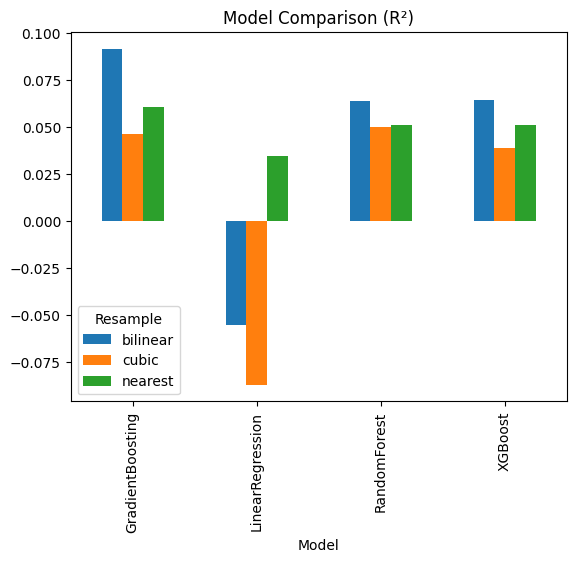

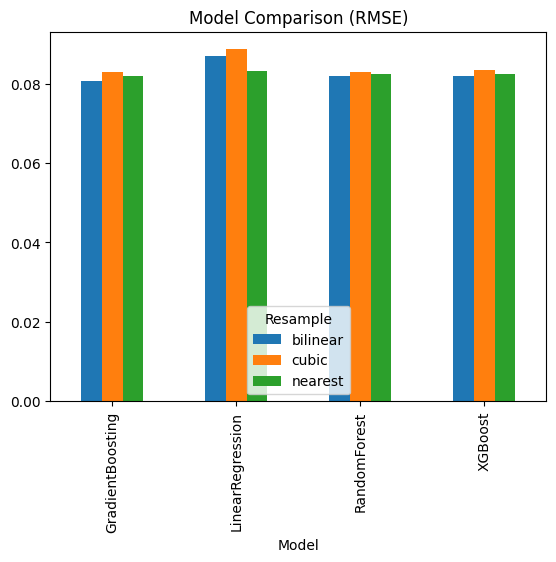

In [53]:
new_results_df.pivot(index='Model', columns='Resample', values='R2').plot(kind='bar')
plt.title("Model Comparison (R²)")
plt.show()
new_results_df.pivot(index='Model', columns='Resample', values='RMSE').plot(kind='bar')
plt.title("Model Comparison (RMSE)")
plt.show()

In [43]:
train_list, test_list = resamples['bilinear']

# combine into full dataframes
train_df = pd.concat(train_list, ignore_index=True)
test_df  = pd.concat(test_list, ignore_index=True)

# --- split test in half spatially (by x) ---
threshold = test_df['X'].median()
test_half1 = test_df[test_df['X'] < threshold]
test_half2 = test_df[test_df['X'] >= threshold]

# move half into training
train_df = pd.concat([train_df, test_half2], ignore_index=True)
test_df  = test_half1

# define target + features
target_col = 'UAV_NDVI'
feature_cols = ['L_NDVI', 'Band1', 'Band2', 'Band3', 'Band4', 'Band5', 'Band6', 'Band7', 
            'AEROSOL_Band_1', 'PIXEL_Band_1', 'RADSAT_Band_1']

X_train = train_df[feature_cols]
y_train = train_df[target_col]

X_test = test_df[feature_cols]
y_test = test_df[target_col]

# train model
model = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
model.fit(X_train, y_train)

# predict
y_pred = model.predict(X_test)

# evaluate
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"R²: {r2:.4f}")
print(f"RMSE: {rmse:.4f}")

R²: 0.0917
RMSE: 0.0806


In [44]:
test_plot = test_df.copy()
test_plot['pred'] = y_pred
test_plot['error'] = test_plot['pred'] - test_plot['UAV_NDVI']
vmin = test_plot['UAV_NDVI'].quantile(0.05)
vmax = test_plot['UAV_NDVI'].quantile(0.95)

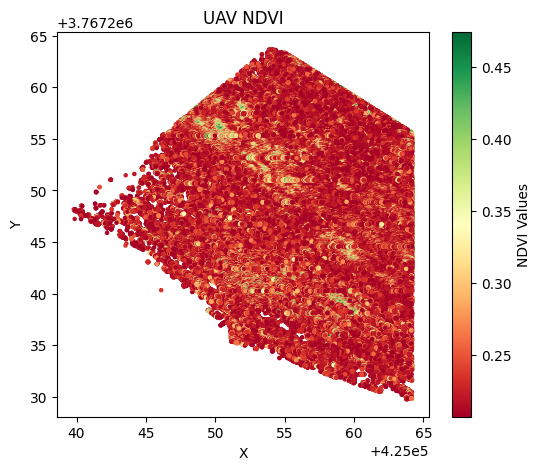

In [51]:

plt.figure(figsize=(6,5))
plt.scatter(test_plot['X'], test_plot['Y'],
            c=test_plot['UAV_NDVI'],
            cmap='RdYlGn',
            s=5,
            vmin=vmin, vmax=vmax)

plt.colorbar(label='NDVI Values')
plt.title("UAV NDVI")
plt.xlabel("X")
plt.ylabel("Y")
plt.show()

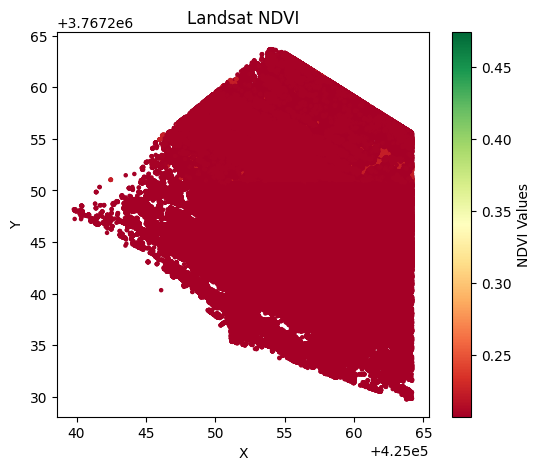

In [50]:
plt.figure(figsize=(6,5))
plt.scatter(test_plot['X'], test_plot['Y'],
            c=test_plot['L_NDVI'],
            cmap='RdYlGn',
            s=5,
            vmin=vmin, vmax=vmax)

plt.colorbar(label='NDVI Values')
plt.title("Landsat NDVI")
plt.xlabel("X")
plt.ylabel("Y")
plt.show()

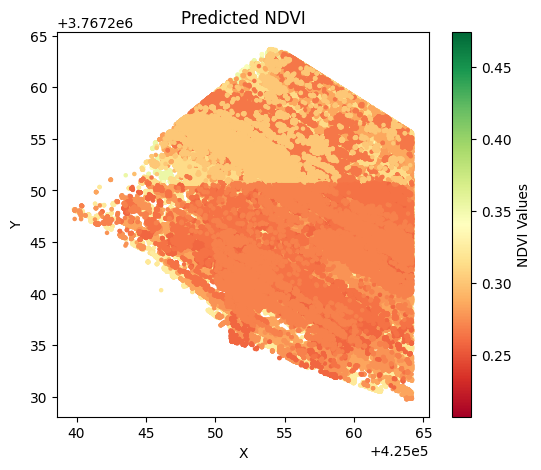

In [52]:
plt.figure(figsize=(6,5))
plt.scatter(test_plot['X'], test_plot['Y'],
            c=test_plot['pred'],
            cmap='RdYlGn',
            s=5,
            vmin=vmin, vmax=vmax)

plt.colorbar(label='NDVI Values')
plt.title("Predicted NDVI")
plt.xlabel("X")
plt.ylabel("Y")
plt.show()

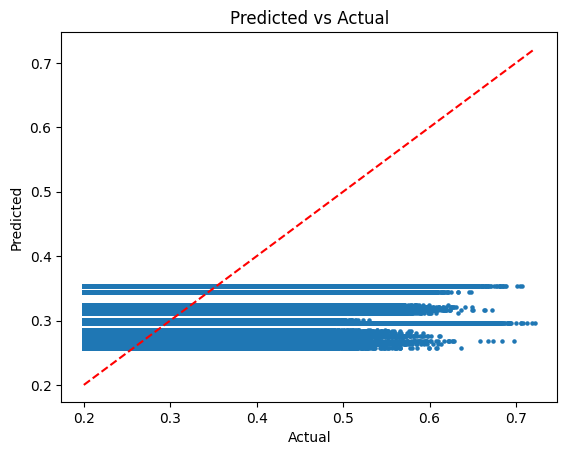

In [47]:
plt.scatter(y_test, y_pred, s=5)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Predicted vs Actual")

# diagonal line
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--')

plt.show()